X shape: (500, 400)
logits shape: (500,)
分类标签 y_clf shape: (500,)


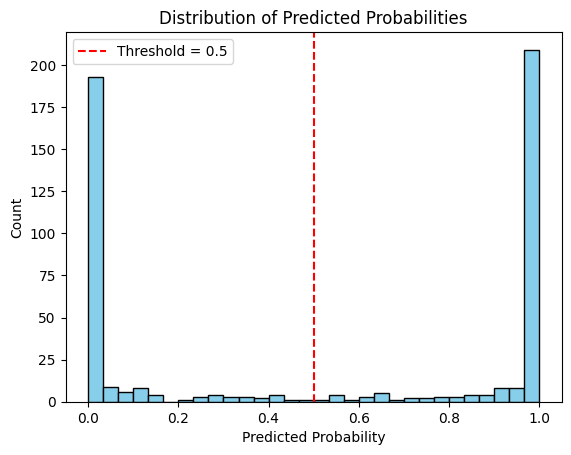

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split


n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))

# 分类标签
X_logits = (
    X[:,50:80].sum(axis=1)*1.5 +    # 代谢模块（正相关）
    X[:,300:330].sum(axis=1)*(-2.0) # 信号通路模块（负相关）
)

# sigmoid 转概率
prob = 1 / (1 + np.exp(-X_logits))

# 二分类标签
y_clf = (prob > 0.5).astype(int)

# 打印结果检查
print("X shape:", X.shape)          # (500, 400)
print("logits shape:", X_logits.shape)  # (500,)
print("分类标签 y_clf shape:", y_clf.shape)  # (500,1)

# Step 4: 可视化标签分布
plt.hist(prob, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities")
plt.legend()
plt.show()

# 数据准备
X_train, X_val, y_train, y_val = train_test_split(X, y_clf, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)